# Aprendizado de Máquina Aplicado à Predição de Doenças Crônicas: Um Estudo de Caso de Hipertensão Arterial

# 1. Importação das Bibliotecas Necessárias

In [2]:
%load_ext autoreload
%autoreload 2
from funcoes_mecai_v3 import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Carregar Dados

In [3]:
# Exemplo de uso da função
path = 'dados/EXAMES-PNS-2013-FINAL_05052023.xlsx'
teste = 0.20
df, df_train, df_test = carregar_dividir_dados(path, teste)

Carregar os dados do arquivo Excel...

Conjunto de Dados Original:
Tamanho do conjunto original: (8952, 509)

Ajustar e filtrar variáveis de interesse...

Removendo exemplos que não compõem a população de interesse...
Removidos 1016 pessoas que não consentiram ou não enviaram o questionário da pesquisa.
Removidas 101 mulheres grávidas.
Removidas 118 pessoas com diagnóstico de hipertensão apenas durante a gravidez.

Construção da variável alvo: pessoas com Pressão arterial sistólica superior a 140mmHg ou Pressão arterial diastólica 90mmHg

Ajustando os dados...

Renomeando colunas

Remover colunas usadas no filtro da população.

Ajustar declaração de valor nulo NaN e #NULL! por np.nan.

Removendo 6 linhas com a região nula.

Removendo 7 linhas com a maioria dos registros nulos.

Divisão dos dados em Treino e Teste ...

 Conjunto de Dados de Desenvolvimento:
Tamanho do conjunto desenvolvimento: (6203, 103)
Distribuição da variável alvo no conjunto desenvolvimento:
target
0    82.959858
1

# 3. Feature Engineering

In [4]:
df_train_fe = add_variaveis_ajustadas(df_train)


Variáveis Demográficas ...

    Faixa Etária:
Distribuição da Faixa Etária:
faixa_etaria
30-39    24.969770
40-49    23.720274
18-29    19.044740
50-59    15.860540
60-69     9.955663
70-79     4.594921
80+       1.854091
Name: proportion, dtype: float64

    Número de Moradores:
Distribuição do Número de Moradores:
faixa_num_mor
3     25.876663
4     22.067715
2     20.918984
1     11.386538
5     10.862555
6+     8.887545
Name: proportion, dtype: float64

    Estado Civil:
Distribuição do Estado Civil:
estado_civil_ag
2    47.682386
1    40.205562
3     6.690850
4     5.421201
Name: proportion, dtype: float64

    Etnia negra:
Distribuição do Etnia negra:
etnia_negra
1    62.837565
2    37.162435
Name: proportion, dtype: float64

Variáveis Socioeconômicas ...

    Renda Total:
Distribuição do Renda Total:
count     4962.000000
mean      1082.676743
std       1777.582943
min          0.000000
25%        100.000000
50%        678.000000
75%       1200.000000
max      36500.000000
Name

In [5]:
df_test_fe = add_variaveis_ajustadas(df_test)


Variáveis Demográficas ...

    Faixa Etária:
Distribuição da Faixa Etária:
faixa_etaria
30-39    27.558421
40-49    21.031426
50-59    17.405318
18-29    17.324738
60-69    10.475423
70-79     4.190169
80+       2.014504
Name: proportion, dtype: float64

    Número de Moradores:
Distribuição do Número de Moradores:
faixa_num_mor
3     26.510878
4     22.159549
2     20.467365
5     11.603546
1     10.475423
6+     8.783239
Name: proportion, dtype: float64

    Estado Civil:
Distribuição do Estado Civil:
estado_civil_ag
2    47.058824
1    41.659952
3     6.526994
4     4.754230
Name: proportion, dtype: float64

    Etnia negra:
Distribuição do Etnia negra:
etnia_negra
1    61.482675
2    38.517325
Name: proportion, dtype: float64

Variáveis Socioeconômicas ...

    Renda Total:
Distribuição do Renda Total:
count     1241.000000
mean      1173.591459
std       2572.327381
min          0.000000
25%         50.000000
50%        678.000000
75%       1200.000000
max      40200.000000
Name

In [6]:
df_fe = add_variaveis_ajustadas(df)


Variáveis Demográficas ...

    Faixa Etária:
Distribuição da Faixa Etária:
faixa_etaria
30-39    25.487667
40-49    23.182331
18-29    18.700629
50-59    16.169595
60-69    10.059649
70-79     4.513945
80+       1.886184
Name: proportion, dtype: float64

    Número de Moradores:
Distribuição do Número de Moradores:
faixa_num_mor
3     26.003547
4     22.086087
2     20.828631
1     11.204256
5     11.010801
6+     8.866677
Name: proportion, dtype: float64

    Estado Civil:
Distribuição do Estado Civil:
estado_civil_ag
2    47.557633
1    40.496534
3     6.658069
4     5.287764
Name: proportion, dtype: float64

    Etnia negra:
Distribuição do Etnia negra:
etnia_negra
1    62.5665
2    37.4335
Name: proportion, dtype: float64

Variáveis Socioeconômicas ...

    Renda Total:
Distribuição do Renda Total:
count     6203.000000
mean      1100.865549
std       1962.601613
min          0.000000
25%        100.000000
50%        678.000000
75%       1200.000000
max      40200.000000
Name: re

# 4. Seleção de Variáveis

## 4.1 Analisando as variáveis de interesse

Avaliar para cada variável:
- **Coeficiente de Correlação de Cramér's V**:
    - 0 a 0.1: Associação muito fraca
    - 0.1 a 0.3: Associação fraca
    - 0.3 a 0.5: Associação moderada
    - 0.5 a 0.7: Associação forte
    - 0.7 a 1: Associação muito forte
- **Information Value (IV)** para uma variável categórica em relação ao target binário:
    - IV < 0.02: Não útil para predição
    - 0.02 ≤ IV < 0.1: Previsão fraca
    - 0.1 ≤ IV < 0.3: Previsão média
    - IV ≥ 0.3: Forte previsão


In [6]:
# Variáveis  de interesse inicial
variaveis_inicial = ['faixa_etaria', 'sexo','regiao', 'etnia_negra', 'faixa_num_mor', 'conj_comp', 
           'estado_civil_ag', 'trabalho', 'faixa_renda_sl', 'plano_saude',
           'diag_renalc', 'diag_diab_rec', 'diag_colest_rec', 'diag_dcore', 'diag_avc',
           'feijao_consumo', 'salada_consumo', 'verd_legu_consumo', 'peixe_consumo', 
           'suco_consumo', 'frutas_consumo','tipo_refri_rec', 'tipo_leite_rec', 
           'doces_consumo', 'freq_subst_ref',  'consumo_sal_rec', 'alcool', 
           'nivel_atv_fisica', 'fumante_hist', 'med_dormir','cintura_risco_aumentado', 
           'cintura_risco_muito_aumentado', 'class_imc','pcp_saude_rec', 'angina', 
            'cat_egfr_afro', 'cat_glicose', 'colesterol_ideal']

In [10]:
# Variáveis  de interesse - 38
variaveis = ['faixa_etaria', 'sexo','regiao', 'etnia_negra', 'faixa_num_mor', 'conj_comp', 
           'faixa_renda_sl', 'plano_saude',
           'diag_renalc', 'diag_diab_rec', 'diag_dcore', 'diag_avc',
           'feijao_consumo', 'salada_consumo', 'verd_legu_consumo', 'peixe_consumo', 
           'suco_consumo', 'frutas_consumo','tipo_refri_rec', 'tipo_leite_rec', 
           'doces_consumo', 'freq_subst_ref',  'consumo_sal_rec', 'alcool', 
           'nivel_atv_fisica', 'fumante_hist', 'med_dormir', 'class_imc',
            'pcp_saude_rec', 'angina', 'cat_egfr_afro', 'cat_glicose', 'colesterol_ideal']

### Verificando associação entre as variáveis preditivas e a variável alvo

In [8]:
# Calcular o resumo das variáveis categóricas
summary_df = summarize_categorical_features(df_train_fe, variaveis_inicial,'target')

In [9]:
summary_df.head(40)

,Variable,Null Proportion,Cramér's V,Information Value,Cramér's V Classification,IV Classification
0,faixa_etaria,0.0,0.265739,0.503663,Associação fraca,Forte previsão
1,sexo,0.0,0.116737,0.098608,Associação fraca,Previsão fraca
2,regiao,0.0,0.121167,0.107018,Associação fraca,Previsão média
3,etnia_negra,0.0,0.017194,0.003656,Associação muito fraca,Não útil para predição
4,faixa_num_mor,0.0,0.116944,0.093313,Associação fraca,Previsão fraca
5,conj_comp,0.0,0.031662,0.008689,Associação muito fraca,Não útil para predição
6,estado_civil_ag,0.0,0.139786,0.122529,Associação fraca,Previsão média
7,trabalho,0.0,0.025838,0.006324,Associação muito fraca,Não útil para predição
8,faixa_renda_sl,0.0,0.096287,0.082195,Associação muito fraca,Previsão fraca
9,plano_saude,0.0,0.047278,0.018894,Associação muito fraca,Não útil para predição


In [10]:
# Obter a lista de variáveis significativas que 
significant_variables = get_significant_variables(summary_df)

In [11]:
significant_variables

['faixa_etaria',
 'sexo',
 'regiao',
 'faixa_num_mor',
 'estado_civil_ag',
 'faixa_renda_sl',
 'doces_consumo',
 'freq_subst_ref',
 'consumo_sal_rec',
 'nivel_atv_fisica',
 'fumante_hist',
 'cintura_risco_aumentado',
 'cintura_risco_muito_aumentado',
 'class_imc',
 'cat_egfr_afro',
 'cat_glicose',
 'colesterol_ideal']

### Calcular Coeficiente de Cramér's V para

In [12]:
low_corr_vars, high_corr_pairs = calculate_cramers_v(df_fe, significant_variables)

In [13]:
low_corr_vars

['estado_civil_ag',
 'consumo_sal_rec',
 'faixa_etaria',
 'faixa_num_mor',
 'cat_egfr_afro',
 'sexo',
 'doces_consumo',
 'colesterol_ideal',
 'fumante_hist',
 'freq_subst_ref',
 'faixa_renda_sl',
 'nivel_atv_fisica',
 'cat_glicose',
 'regiao']

In [14]:
high_corr_pairs

[('cintura_risco_aumentado',
  'cintura_risco_muito_aumentado',
  0.6232680180072337),
 ('cintura_risco_aumentado', 'class_imc', 0.5750872654507698),
 ('cintura_risco_muito_aumentado',
  'cintura_risco_aumentado',
  0.6232680180072337),
 ('cintura_risco_muito_aumentado', 'class_imc', 0.6058504187186871),
 ('class_imc', 'cintura_risco_aumentado', 0.5750872654507697),
 ('class_imc', 'cintura_risco_muito_aumentado', 0.6058504187186871)]

In [15]:
low_corr_vars, high_corr_pairs = calculate_cramers_v(df_fe, variaveis_inicial)

In [16]:
low_corr_vars

['diag_dcore',
 'faixa_num_mor',
 'alcool',
 'doces_consumo',
 'frutas_consumo',
 'diag_renalc',
 'tipo_refri_rec',
 'plano_saude',
 'peixe_consumo',
 'suco_consumo',
 'med_dormir',
 'regiao',
 'verd_legu_consumo',
 'faixa_etaria',
 'etnia_negra',
 'tipo_leite_rec',
 'pcp_saude_rec',
 'colesterol_ideal',
 'freq_subst_ref',
 'nivel_atv_fisica',
 'consumo_sal_rec',
 'diag_avc',
 'cat_egfr_afro',
 'sexo',
 'fumante_hist',
 'salada_consumo',
 'angina',
 'cat_glicose',
 'feijao_consumo']

In [17]:
high_corr_pairs

[('conj_comp', 'estado_civil_ag', 0.579130072181311),
 ('estado_civil_ag', 'conj_comp', 0.579130072181311),
 ('trabalho', 'faixa_renda_sl', 0.646147312996441),
 ('faixa_renda_sl', 'trabalho', 0.6461473129964409),
 ('diag_diab_rec', 'diag_colest_rec', 0.5277112311841544),
 ('diag_colest_rec', 'diag_diab_rec', 0.5277112311841544),
 ('cintura_risco_aumentado',
  'cintura_risco_muito_aumentado',
  0.6232680180072337),
 ('cintura_risco_aumentado', 'class_imc', 0.5750872654507698),
 ('cintura_risco_muito_aumentado',
  'cintura_risco_aumentado',
  0.6232680180072337),
 ('cintura_risco_muito_aumentado', 'class_imc', 0.6058504187186871),
 ('class_imc', 'cintura_risco_aumentado', 0.5750872654507697),
 ('class_imc', 'cintura_risco_muito_aumentado', 0.6058504187186871)]

### Prepararação dos dados para o Modelo

In [11]:
df_train_v1 = df_train_fe[variaveis + ['target']]

In [12]:
df_train_v1.shape

(4962, 34)

In [13]:
df_test_v1 = df_test_fe[variaveis + ['target']]

In [14]:
df_test_v1.shape

(1241, 34)

In [15]:
df_v1 = df_fe[variaveis + ['target']]

In [16]:
df_v1.shape

(6203, 34)

### Codificação em binária

In [17]:
df_v2 = encode_data(df_v1, 'target')

In [18]:
df_v2.shape

(6203, 86)

In [19]:
df_train_v2 = encode_data(df_train_v1, 'target')

In [20]:
df_train_v2.shape

(4962, 86)

In [21]:
df_test_v2 = encode_data(df_test_v1, 'target')

In [22]:
df_test_v2.shape

(1241, 86)

In [23]:
verificar_colunas(df_train_v2, df_test_v2)

Os DataFrames têm as mesmas colunas.


## 4.2 Seleção de Variáveis por Algoritmos

#### Seleção com os dados balanceados via SMOTE

In [31]:
selected_features_df_v2 = variable_selection_cv(df_train_v2, 'target')

Executando Boruta XGB: 100%|██████████| 1/1 [00:15<00:00, 15.46s/etapa]


In [32]:
# Filtrar variáveis selecionadas por dois ou mais métodos
filtered_features_boruta = selected_features_df_v2[selected_features_df_v2['Boruta'] == True]['Variable'].tolist()

In [33]:
len(filtered_features_boruta)

59

In [34]:
filtered_features_boruta

['faixa_etaria_30-39',
 'faixa_etaria_40-49',
 'faixa_etaria_50-59',
 'sexo_2',
 'regiao_2.0',
 'regiao_5.0',
 'etnia_negra_2',
 'faixa_num_mor_2',
 'faixa_num_mor_3',
 'faixa_num_mor_4',
 'faixa_num_mor_5',
 'faixa_num_mor_6+',
 'conj_comp_2',
 'faixa_renda_sl_3',
 'faixa_renda_sl_5',
 'faixa_renda_sl_6',
 'faixa_renda_sl_7',
 'diag_diab_rec_2.0',
 'diag_diab_rec_3.0',
 'diag_avc_2.0',
 'feijao_consumo_2',
 'feijao_consumo_3',
 'feijao_consumo_4',
 'salada_consumo_2',
 'salada_consumo_4',
 'verd_legu_consumo_2',
 'verd_legu_consumo_3',
 'verd_legu_consumo_4',
 'peixe_consumo_2',
 'peixe_consumo_3',
 'suco_consumo_2',
 'suco_consumo_3',
 'suco_consumo_4',
 'frutas_consumo_2',
 'frutas_consumo_3',
 'frutas_consumo_4',
 'tipo_refri_rec_4.0',
 'tipo_leite_rec_2.0',
 'tipo_leite_rec_3.0',
 'tipo_leite_rec_4.0',
 'doces_consumo_2',
 'doces_consumo_3',
 'doces_consumo_4',
 'freq_subst_ref_2',
 'freq_subst_ref_3',
 'freq_subst_ref_4',
 'consumo_sal_rec_2',
 'consumo_sal_rec_3',
 'alcool_2.0',

In [35]:
df_train_v3 = df_train_v2[filtered_features_boruta + ['target']]

In [36]:
df_train_v3.shape

(4962, 60)

In [37]:
df_test_v3 = df_test_v2[filtered_features_boruta + ['target']]

In [38]:
df_test_v3.shape

(1241, 60)

In [46]:
df_v3 = df_v2[filtered_features_boruta + ['target']]

In [47]:
df_v3.shape

(6203, 60)

# 5. Treinando Modelos

## 5.1 Treinamento usando seleção Boruta

### Sem validação cruzada

Avaliando Modelos: 100%|██████████| 9/9 [00:20<00:00,  2.26s/it]


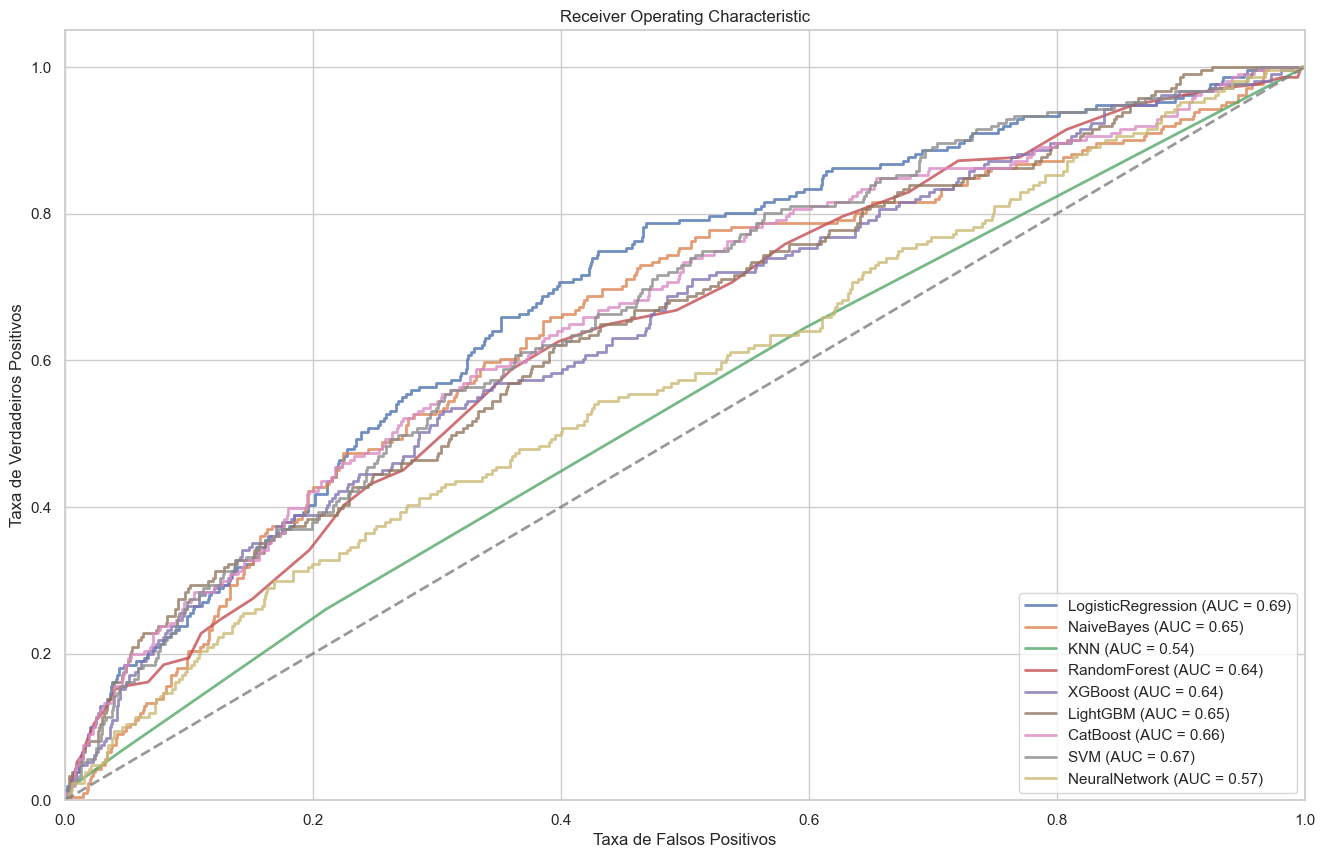

In [41]:
resultado_brt = evaluate_models(df_train_v3, df_test_v3, 'target')

In [42]:
resultado_brt

,Model,AUC,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.69,0.65,0.27,0.64,0.38
1,NaiveBayes,0.65,0.70,0.28,0.48,0.35
2,KNN,0.54,0.80,0.23,0.07,0.10
3,RandomForest,0.64,0.83,0.00,0.00,0.00
4,XGBoost,0.64,0.70,0.27,0.45,0.34
5,LightGBM,0.65,0.70,0.27,0.45,0.33
6,CatBoost,0.66,0.69,0.28,0.52,0.36
7,SVM,0.67,0.67,0.27,0.53,0.36
8,NeuralNetwork,0.57,0.77,0.27,0.21,0.24


### Com validação cruzada

Avaliando Modelos: 100%|██████████| 9/9 [03:04<00:00, 20.52s/it]


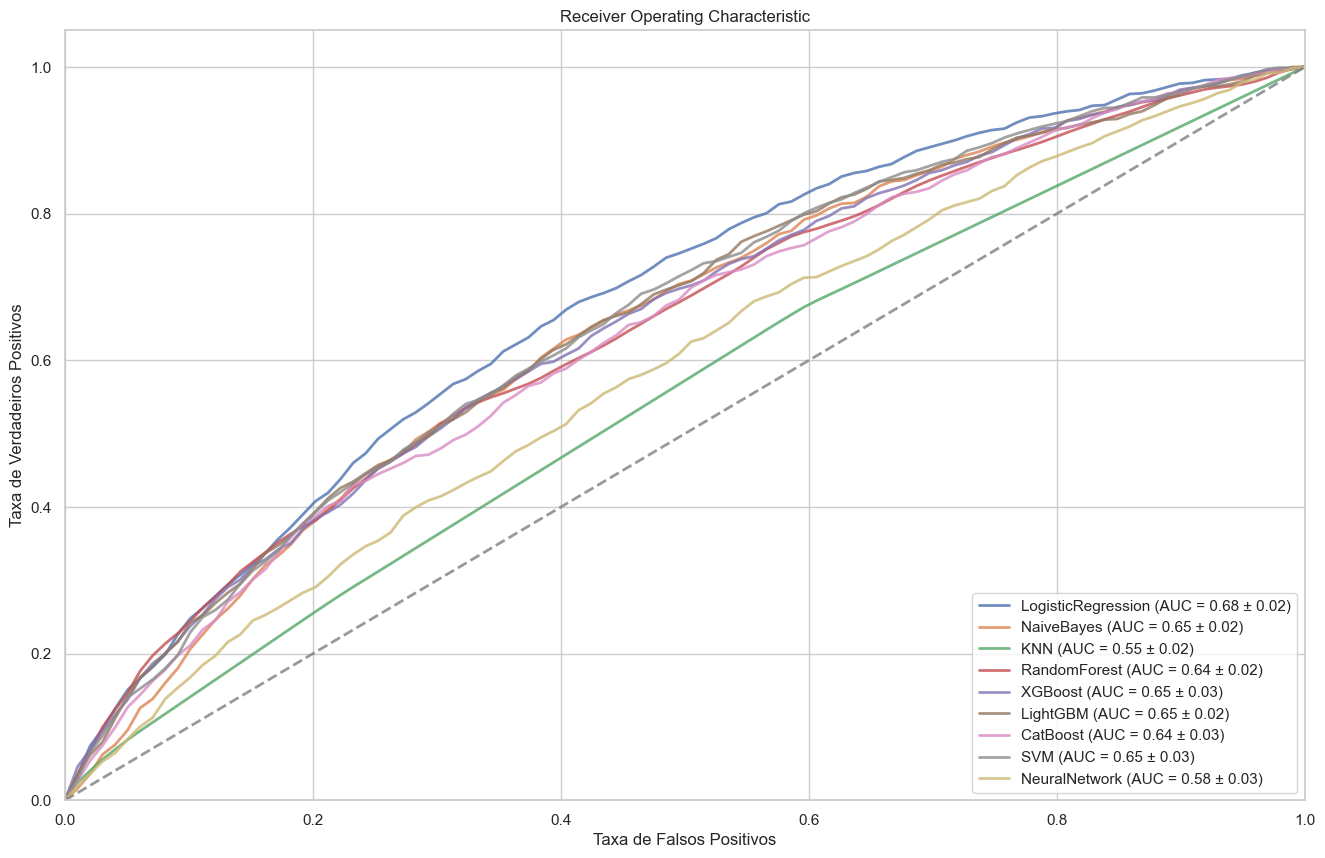

In [48]:
resultado_brt_cv = evaluate_models_cv(df_v3, 'target', cv=10)

In [50]:
resultado_brt_cv

,Model,AUC,AUC_STD,Accuracy,Accuracy_STD,Precision,Precision_STD,Recall,Recall_STD,F1,F1_STD
0,LogisticRegression,0.68,0.02,0.64,0.02,0.26,0.02,0.61,0.05,0.36,0.02
1,NaiveBayes,0.65,0.02,0.71,0.01,0.27,0.03,0.42,0.05,0.33,0.03
2,KNN,0.55,0.02,0.80,0.01,0.26,0.07,0.08,0.03,0.12,0.04
3,RandomForest,0.64,0.02,0.83,0.00,0.35,0.40,0.01,0.01,0.01,0.01
4,XGBoost,0.65,0.03,0.70,0.02,0.27,0.02,0.43,0.06,0.33,0.03
5,LightGBM,0.65,0.02,0.69,0.02,0.26,0.02,0.48,0.06,0.34,0.03
6,CatBoost,0.64,0.03,0.68,0.02,0.26,0.02,0.47,0.05,0.33,0.03
7,SVM,0.65,0.03,0.65,0.02,0.25,0.02,0.52,0.06,0.34,0.03
8,NeuralNetwork,0.58,0.03,0.76,0.02,0.25,0.04,0.21,0.03,0.23,0.03


## 5.2 Treinamento usando todas as variáveis

### Sem validação cruzada

Avaliando Modelos: 100%|██████████| 9/9 [00:22<00:00,  2.53s/it]


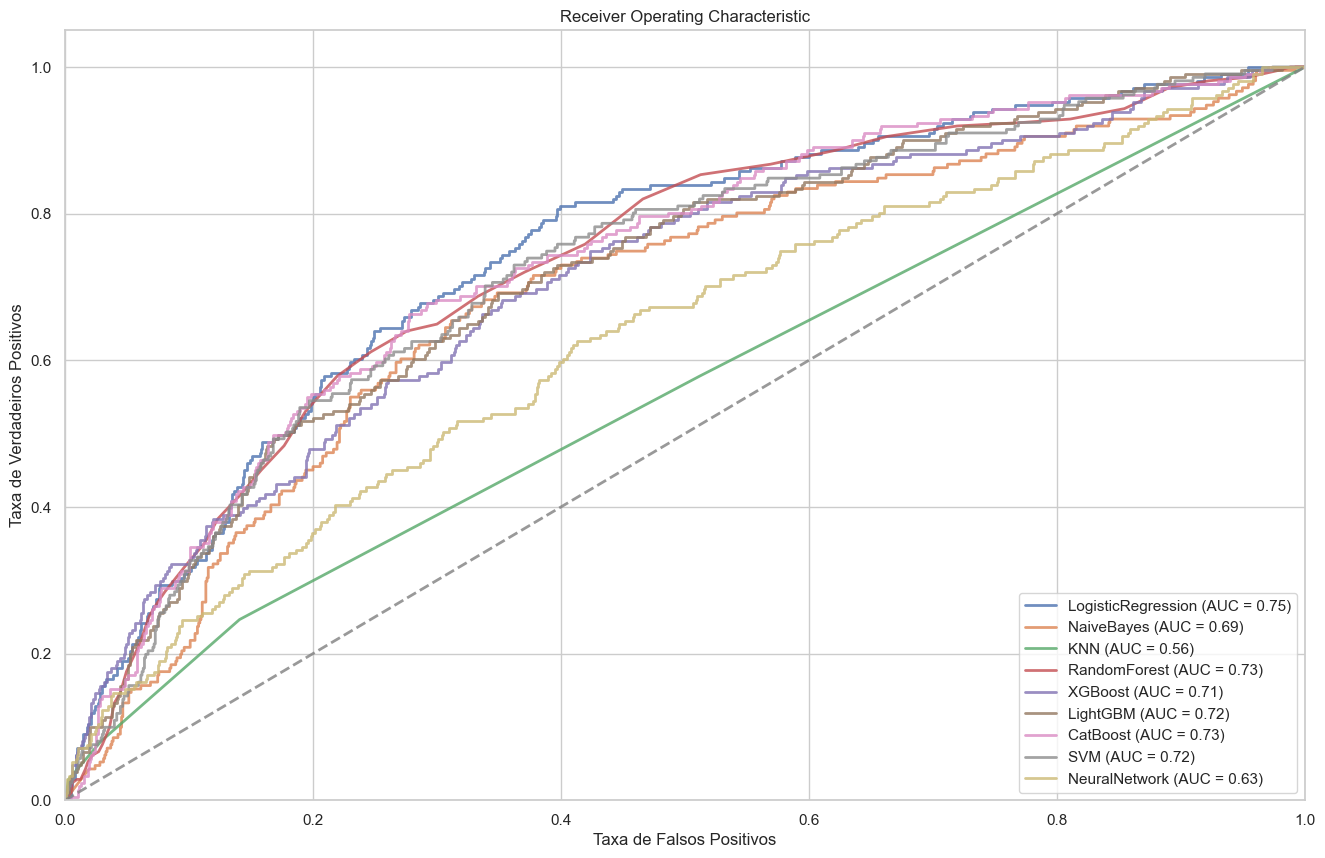

In [51]:
resultado_all = evaluate_models(df_train_v2, df_test_v2, 'target')

In [52]:
resultado_all

,Model,AUC,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.75,0.70,0.32,0.68,0.44
1,NaiveBayes,0.69,0.78,0.35,0.36,0.36
2,KNN,0.56,0.82,0.36,0.08,0.13
3,RandomForest,0.73,0.83,0.33,0.01,0.02
4,XGBoost,0.71,0.74,0.32,0.48,0.38
5,LightGBM,0.72,0.75,0.35,0.52,0.42
6,CatBoost,0.73,0.74,0.35,0.58,0.43
7,SVM,0.72,0.72,0.32,0.59,0.42
8,NeuralNetwork,0.63,0.78,0.32,0.25,0.28


### Com validação cruzada

Avaliando Modelos: 100%|██████████| 9/9 [02:38<00:00, 17.64s/it]


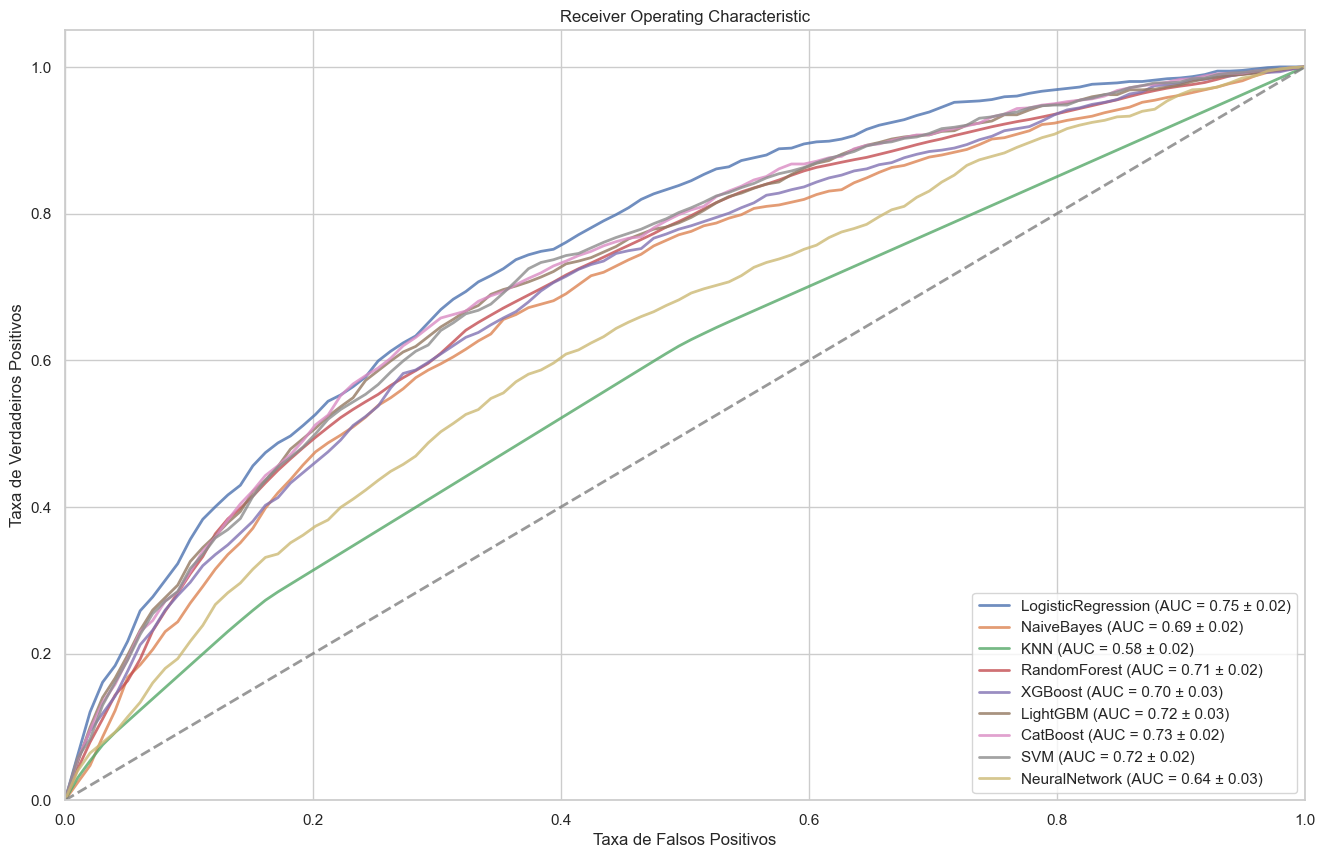

In [57]:
resultado_cv = evaluate_models_cv(df_v2, 'target', cv=10)

In [58]:
resultado_cv

,Model,AUC,AUC_STD,Accuracy,Accuracy_STD,Precision,Precision_STD,Recall,Recall_STD,F1,F1_STD
0,LogisticRegression,0.75,0.02,0.69,0.02,0.31,0.02,0.68,0.06,0.43,0.03
1,NaiveBayes,0.69,0.02,0.77,0.01,0.34,0.04,0.34,0.05,0.34,0.04
2,KNN,0.58,0.02,0.82,0.01,0.34,0.07,0.08,0.02,0.13,0.03
3,RandomForest,0.71,0.02,0.83,0.00,0.48,0.39,0.01,0.01,0.02,0.02
4,XGBoost,0.70,0.03,0.74,0.02,0.32,0.02,0.47,0.05,0.38,0.03
5,LightGBM,0.72,0.03,0.74,0.01,0.34,0.02,0.51,0.06,0.40,0.03
6,CatBoost,0.73,0.02,0.72,0.02,0.33,0.02,0.59,0.04,0.42,0.02
7,SVM,0.72,0.02,0.71,0.02,0.31,0.02,0.60,0.06,0.41,0.03
8,NeuralNetwork,0.64,0.03,0.77,0.01,0.31,0.04,0.26,0.04,0.28,0.03


## Ajuste de Hiperparâmetros

In [25]:
target = 'target'
X_train = df_train_v2.drop(columns=[target])
y_train = df_train_v2[target]
X_test = df_test_v2.drop(columns=[target])
y_test = df_test_v2[target]

### CatBoost

#### Random Search

In [26]:
# Inicializar o classificador CatBoost com verbose=0 para suprimir logs
model = CatBoostClassifier(loss_function='Logloss', random_state=42, verbose=0)

# Definir as distribuições de hiperparâmetros
param_dist = {
    'iterations': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'scale_pos_weight': [(1 - 0.17) / 0.17]  # Ajustar conforme o desbalanceamento
}

# Usar 'roc_auc' como métrica de avaliação
scorer = make_scorer(roc_auc_score)

# Realizar Random Search com validação cruzada
random_search_cat = RandomizedSearchCV(model, param_distributions=param_dist,
                                   n_iter=50, cv=10, scoring=scorer, 
                                   n_jobs=-1, random_state=42)
random_search_cat.fit(X_train, y_train)

# Obter os melhores hiperparâmetros
best_params_cat = random_search_cat.best_params_

# Avaliar o modelo com os melhores hiperparâmetros
best_model_cat = random_search_cat.best_estimator_
y_prob = best_model_cat.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

# Imprimir os melhores hiperparâmetros e a AUC
print(f"Melhores Hiperparâmetros: {best_params_cat}")
print(f"AUC: {auc:.4f}")

Melhores Hiperparâmetros: {'scale_pos_weight': 4.88235294117647, 'learning_rate': 0.01, 'l2_leaf_reg': 9, 'iterations': 1000, 'depth': 3}
AUC: 0.7526


### Regressão Logística

In [28]:
# Imprimir os melhores hiperparâmetros e a AUC
print(f"Melhores Hiperparâmetros: {best_params_rl}")
print(f"AUC: {auc_rl:.4f}")

Melhores Hiperparâmetros: {'solver': 'saga', 'penalty': 'none', 'class_weight': 'balanced', 'C': 0.1}
AUC: 0.7452


# 7. Interpretabilidade

### Catboost

In [29]:
target = 'target'
X_train = df_train_v2.drop(columns=[target])
y_train = df_train_v2[target]
X_test = df_test_v2.drop(columns=[target])
y_test = df_test_v2[target]

In [30]:
# Obter as probabilidades preditas para a classe positiva
y_prob = random_search_cat.predict_proba(X_test)[:, 1]

# Calcular a AUC
auc = roc_auc_score(y_test, y_prob)

print(f'AUC: {auc:.4f}')

AUC: 0.7526


In [36]:
# Treinar o modelo CatBoost
catboost_model = train_catboost_model(X_train, y_train)

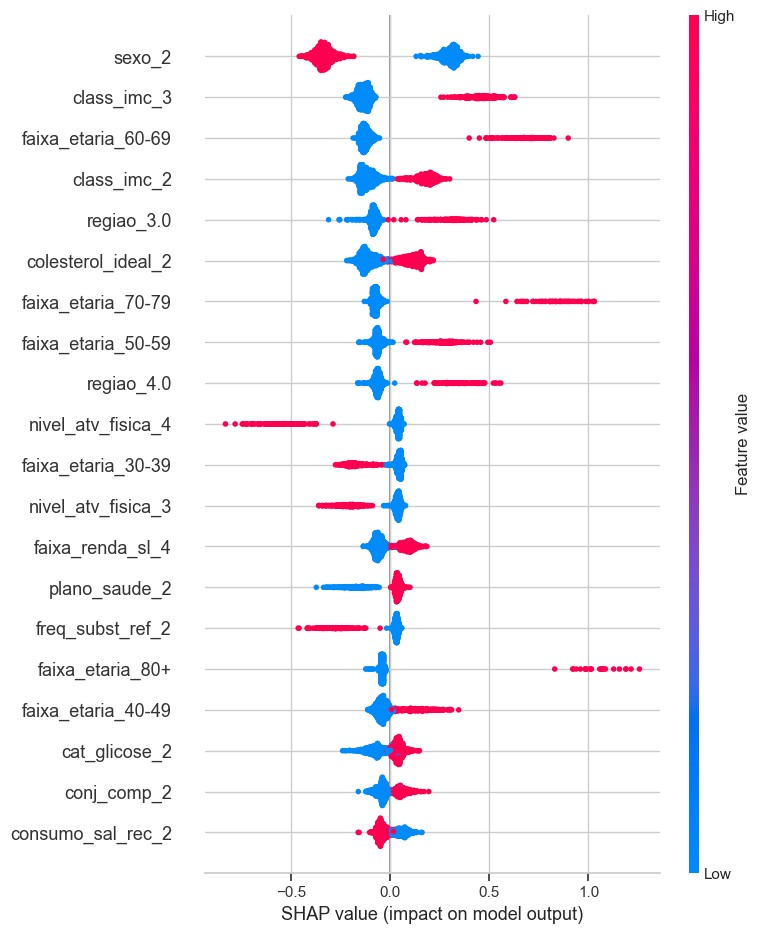

In [37]:
# Plotar valores SHAP
plot_shap_values_catboost(catboost_model, X_test)

### Regressão Logística

In [31]:
# Treinar o modelo de Regressão Logística
logistic_model, scaler = train_logistic_model(X_train, y_train)

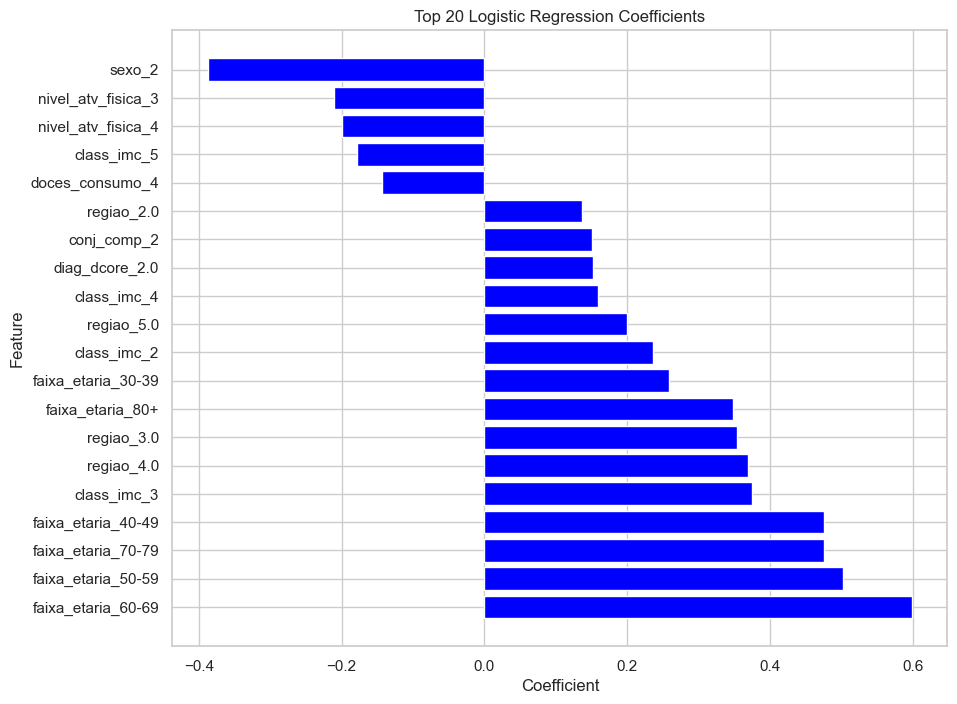

               Feature  Coefficient  Exp(Coefficient)  Abs(Coefficient)
6               sexo_2    -0.387587          0.678693          0.387587
67  nivel_atv_fisica_3    -0.210323          0.810322          0.210323
68  nivel_atv_fisica_4    -0.199423          0.819203          0.199423
74         class_imc_5    -0.178687          0.836368          0.178687
58     doces_consumo_4    -0.143135          0.866637          0.143135
7           regiao_2.0     0.136842          1.146647          0.136842
17         conj_comp_2     0.151316          1.163364          0.151316
30      diag_dcore_2.0     0.152071          1.164242          0.152071
73         class_imc_4     0.158699          1.171985          0.158699
10          regiao_5.0     0.199465          1.220749          0.199465
71         class_imc_2     0.235825          1.265953          0.235825
0   faixa_etaria_30-39     0.259186          1.295875          0.259186
5     faixa_etaria_80+     0.348740          1.417280          0

In [32]:
# Interpretar os coeficientes
coef_df = interpret_logistic_model(logistic_model, X_train)
print(coef_df)